# Diabetic Readmission Model

Custom scoring model trained on the UCI Diabetic dataset (101,766 hospital encounters).

The model computes a **raw score** per feature — the percentage of training rows where that feature's value matches the readmission label. During prediction, each feature contributes positively or negatively to a patient's total score based on its raw score and its value. Patients with a total score above a learned threshold are predicted as readmitted.

**Label encoding:** Any readmission (`<30` or `>30` days) = 1, no readmission (`NO`) = 0

## Section 1: Imports and Paths

In [21]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score, roc_curve
)

warnings.filterwarnings('ignore')
print('Imports successful')

Imports successful


In [22]:
# Notebook must be run from the neuroshield root directory
BASE_DIR   = os.getcwd()
DATA_PATH  = os.path.join(BASE_DIR, 'data', 'diabetic_data.csv')
OUTPUT_DIR = os.path.join(BASE_DIR, 'data', 'output')
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f'Base directory : {BASE_DIR}')
print(f'Data path      : {DATA_PATH}')
print(f'Output dir     : {OUTPUT_DIR}')

Base directory : /Users/umair/Documents/Denovonet/neuroshield
Data path      : /Users/umair/Documents/Denovonet/neuroshield/data/diabetic/diabetic_data.csv
Output dir     : /Users/umair/Documents/Denovonet/neuroshield/data/output


## Section 2: Load Data

In [23]:
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
print(f'\nReadmitted distribution:')
print(df['readmitted'].value_counts())
df.head(3)

Shape: (101766, 50)

Readmitted distribution:
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO


## Section 3: Label Engineering

- Drop 3 rows where `gender == 'Unknown/Invalid'` (negligible count)
- Binarise `readmitted`: `NO` → 0, `<30` → 1, `>30` → 1

In [24]:
# Drop 3 Unknown/Invalid gender rows
df = df[df['gender'] != 'Unknown/Invalid'].copy()
print(f'Rows after gender filter: {len(df)}')

# Binarise label
df['label'] = (df['readmitted'] != 'NO').astype(int)
df.drop('readmitted', axis=1, inplace=True)

print(f'\nBinary label distribution:')
print(df['label'].value_counts())
print(f'Overall readmission rate: {df["label"].mean()*100:.1f}%')

Rows after gender filter: 101763

Binary label distribution:
label
0    54861
1    46902
Name: count, dtype: int64
Overall readmission rate: 46.1%


## Section 4: Drop Useless Columns

Dropping: row identifiers, high-missingness columns (>40% missing), and columns with zero or near-zero variance.

In [25]:
cols_to_drop = [
    # Identifiers
    'encounter_id', 'patient_nbr',
    # High missingness (>40%)
    'weight', 'medical_specialty', 'max_glu_serum', 'A1Cresult',
    # Zero / near-zero variance
    'examide', 'citoglipton', 'acetohexamide', 'troglitazone',
    'tolbutamide', 'glipizide-metformin', 'glimepiride-pioglitazone',
    'metformin-rosiglitazone', 'metformin-pioglitazone'
]

df.drop(cols_to_drop, axis=1, inplace=True)
print(f'Shape after dropping useless columns: {df.shape}')
print(f'Remaining columns ({len(df.columns)}): {list(df.columns)}')

Shape after dropping useless columns: (101763, 35)
Remaining columns (35): ['race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'tolazamide', 'insulin', 'glyburide-metformin', 'change', 'diabetesMed', 'label']


## Section 5: Feature Engineering

Every feature is transformed to binary (0/1). The original column is dropped immediately after each transformation.

In [26]:
# ── 5a. Race (one-hot, 5 columns) ────────────────────────────────────
race_map = {
    'Caucasian':       'race_caucasian',
    'AfricanAmerican': 'race_african_american',
    'Hispanic':        'race_hispanic',
    'Asian':           'race_asian',
    'Other':           'race_other'
}
for race_val, col_name in race_map.items():
    df[col_name] = (df['race'] == race_val).astype(int)
df.drop('race', axis=1, inplace=True)

# ── 5b. Gender ────────────────────────────────────────────────────────
df['gender_female'] = (df['gender'] == 'Female').astype(int)
df.drop('gender', axis=1, inplace=True)

# ── 5c. Age (elderly = 60+) ───────────────────────────────────────────
elderly_brackets = ['[60-70)', '[70-80)', '[80-90)', '[90-100)']
df['age_elderly'] = df['age'].isin(elderly_brackets).astype(int)
df.drop('age', axis=1, inplace=True)

# ── 5d. Payer Code ────────────────────────────────────────────────────
government_codes = {'MC', 'MD', 'CP', 'CM', 'OG', 'MP'}
private_codes    = {'HM', 'BC', 'UN', 'PO', 'DM', 'CH', 'WC', 'OT', 'SI', 'FR'}
df['payer_government'] = df['payer_code'].isin(government_codes).astype(int)
df['payer_private']    = df['payer_code'].isin(private_codes).astype(int)
df['payer_self_pay']   = (df['payer_code'] == 'SP').astype(int)
df.drop('payer_code', axis=1, inplace=True)

# ── 5e. Admission Type ────────────────────────────────────────────────
df['admission_emergency_urgent'] = df['admission_type_id'].isin([1, 2]).astype(int)
df.drop('admission_type_id', axis=1, inplace=True)

# ── 5f. Discharge Disposition ─────────────────────────────────────────
df['discharge_not_home'] = (df['discharge_disposition_id'] != 1).astype(int)
df.drop('discharge_disposition_id', axis=1, inplace=True)

# ── 5g. Admission Source ──────────────────────────────────────────────
df['admission_from_er'] = (df['admission_source_id'] == 7).astype(int)
df.drop('admission_source_id', axis=1, inplace=True)

print('Steps 5a-5g complete.')
print(f'Shape: {df.shape}')

Steps 5a-5g complete.
Shape: (101763, 41)


In [27]:
# ── 5h. Diagnosis ICD-9 Chapters ─────────────────────────────────────
#
# One binary flag per chapter, set to 1 if ANY of diag_1/2/3
# falls into that ICD-9 chapter.

def get_icd_chapter(code):
    code = str(code).strip()
    if code in ('?', 'nan', ''):
        return None
    if code.upper().startswith('V'):
        return 'vcode'
    if code.upper().startswith('E'):
        return 'ecode'
    try:
        int_part = int(float(code))
        if   1   <= int_part <= 139: return 'infectious'
        elif 140 <= int_part <= 239: return 'neoplasm'
        elif 240 <= int_part <= 279: return 'endocrine'
        elif 280 <= int_part <= 289: return 'blood'
        elif 290 <= int_part <= 319: return 'mental'
        elif 320 <= int_part <= 389: return 'nervous'
        elif 390 <= int_part <= 459: return 'circulatory'
        elif 460 <= int_part <= 519: return 'respiratory'
        elif 520 <= int_part <= 579: return 'digestive'
        elif 580 <= int_part <= 629: return 'genitourinary'
        elif 710 <= int_part <= 739: return 'musculoskeletal'
        elif 780 <= int_part <= 799: return 'ill_defined'
        elif 800 <= int_part <= 999: return 'injury'
        else: return None
    except Exception:
        return None

diag1_ch = df['diag_1'].apply(get_icd_chapter)
diag2_ch = df['diag_2'].apply(get_icd_chapter)
diag3_ch = df['diag_3'].apply(get_icd_chapter)

chapters = [
    'infectious', 'neoplasm', 'endocrine', 'blood', 'mental', 'nervous',
    'circulatory', 'respiratory', 'digestive', 'genitourinary',
    'musculoskeletal', 'ill_defined', 'injury', 'vcode', 'ecode'
]

for chapter in chapters:
    df[f'diag_{chapter}'] = (
        (diag1_ch == chapter) | (diag2_ch == chapter) | (diag3_ch == chapter)
    ).astype(int)

df.drop(['diag_1', 'diag_2', 'diag_3'], axis=1, inplace=True)

print('Step 5h (ICD chapters) complete.')
print(f'Shape: {df.shape}')

chapter_counts = {ch: df[f'diag_{ch}'].sum() for ch in chapters}
print('\nPatients with at least one diagnosis in each chapter:')
for ch, cnt in sorted(chapter_counts.items(), key=lambda x: -x[1]):
    print(f'  diag_{ch:<20} {cnt:>6}')

Step 5h (ICD chapters) complete.
Shape: (101763, 53)

Patients with at least one diagnosis in each chapter:
  diag_circulatory           58671
  diag_endocrine             49914
  diag_respiratory           22515
  diag_genitourinary         17310
  diag_ill_defined           15499
  diag_digestive             13641
  diag_injury                 9967
  diag_musculoskeletal        7532
  diag_vcode                  6688
  diag_mental                 6585
  diag_infectious             6331
  diag_blood                  6326
  diag_neoplasm               6088
  diag_nervous                4064
  diag_ecode                  1818


In [28]:
# ── 5i. Numeric Columns (median thresholds) ───────────────────────────

numeric_transforms = {
    'time_in_hospital':   ('long_stay',             '>=', 4),
    'num_lab_procedures': ('high_lab_procedures',   '>=', 44),
    'num_procedures':     ('had_procedures',        '>=', 1),
    'num_medications':    ('high_medications',      '>=', 15),
    'number_outpatient':  ('had_outpatient_visits', '>',  0),
    'number_emergency':   ('had_emergency_visits',  '>',  0),
    'number_inpatient':   ('had_inpatient_visits',  '>',  0),
    'number_diagnoses':   ('high_diagnoses',        '>=', 8),
}

for orig_col, (new_col, op, thr) in numeric_transforms.items():
    df[new_col] = (df[orig_col] >= thr if op == '>=' else df[orig_col] > thr).astype(int)
    df.drop(orig_col, axis=1, inplace=True)

print('Step 5i (numeric columns) complete.')
print(f'Shape: {df.shape}')

Step 5i (numeric columns) complete.
Shape: (101763, 53)


In [29]:
# ── 5j. Medications (on only) ─────────────────────────────────────────
#
# One binary column per medication:
#   {med}_on : Steady / Up / Down = 1  (patient is currently on this drug)
# Dose-change columns (_changed) are excluded as they add noise.

medications = [
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
    'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone', 'acarbose',
    'miglitol', 'tolazamide', 'insulin', 'glyburide-metformin'
]

for med in medications:
    col = med.replace('-', '_')
    df[f'{col}_on'] = df[med].isin(['Steady', 'Up', 'Down']).astype(int)
    df.drop(med, axis=1, inplace=True)

# ── 5k. Medication Change Flag ────────────────────────────────────────
df['medication_change'] = (df['change'] == 'Ch').astype(int)
df.drop('change', axis=1, inplace=True)

# ── 5l. On Diabetes Medication ────────────────────────────────────────
df['on_diabetes_med'] = (df['diabetesMed'] == 'Yes').astype(int)
df.drop('diabetesMed', axis=1, inplace=True)

print('Steps 5j-5l (medications) complete.')
print(f'Final shape after all feature engineering: {df.shape}')

Steps 5j-5l (medications) complete.
Final shape after all feature engineering: (101763, 53)


## Section 6: Data Validation

In [30]:
feature_df = df.drop('label', axis=1)

print(f'Total features : {feature_df.shape[1]}')
print(f'Total rows     : {feature_df.shape[0]}')

non_binary = [
    (col, set(feature_df[col].unique()))
    for col in feature_df.columns
    if not set(feature_df[col].unique()).issubset({0, 1})
]
if non_binary:
    print('\nWARNING: Non-binary columns found:')
    for col, vals in non_binary:
        print(f'  {col}: {vals}')
else:
    print('\nAll feature columns are binary (0/1). Validation passed.')

print(f'Null values    : {df.isnull().sum().sum()}')
print(f'\nLabel distribution:')
print(df['label'].value_counts())
print(f'Readmission rate: {df["label"].mean()*100:.1f}%')

print(f'\nAll {feature_df.shape[1]} feature names:')
for i, col in enumerate(feature_df.columns, 1):
    print(f'  {i:>3}. {col}')

Total features : 52
Total rows     : 101763

All feature columns are binary (0/1). Validation passed.
Null values    : 0

Label distribution:
label
0    54861
1    46902
Name: count, dtype: int64
Readmission rate: 46.1%

All 52 feature names:
    1. race_caucasian
    2. race_african_american
    3. race_hispanic
    4. race_asian
    5. race_other
    6. gender_female
    7. age_elderly
    8. payer_government
    9. payer_private
   10. payer_self_pay
   11. admission_emergency_urgent
   12. discharge_not_home
   13. admission_from_er
   14. diag_infectious
   15. diag_neoplasm
   16. diag_endocrine
   17. diag_blood
   18. diag_mental
   19. diag_nervous
   20. diag_circulatory
   21. diag_respiratory
   22. diag_digestive
   23. diag_genitourinary
   24. diag_musculoskeletal
   25. diag_ill_defined
   26. diag_injury
   27. diag_vcode
   28. diag_ecode
   29. long_stay
   30. high_lab_procedures
   31. had_procedures
   32. high_medications
   33. had_outpatient_visits
   34. had_e

## Section 7: Train / Test Split (75/25 Stratified)

In [31]:
X = df.drop('label', axis=1)
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f'Training set : {X_train.shape[0]:>6} rows  ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Test set     : {X_test.shape[0]:>6} rows  ({X_test.shape[0]/len(X)*100:.1f}%)')
print(f'\nTraining label distribution:')
print(y_train.value_counts())
print(f'Training readmission rate : {y_train.mean()*100:.1f}%')
print(f'\nTest label distribution:')
print(y_test.value_counts())
print(f'Test readmission rate     : {y_test.mean()*100:.1f}%')

Training set :  76322 rows  (75.0%)
Test set     :  25441 rows  (25.0%)

Training label distribution:
label
0    41146
1    35176
Name: count, dtype: int64
Training readmission rate : 46.1%

Test label distribution:
label
0    13715
1    11726
Name: count, dtype: int64
Test readmission rate     : 46.1%


## Section 8: Model Training

For each binary feature, compute the **raw score** on the training set:

```
raw_score = (rows where feature value == label) / total training rows  ×  100
```

- **Raw score > 50%** → feature positively correlates with readmission
- **Raw score < 50%** → feature negatively correlates
- **Raw score = 50%** → feature has no predictive power

In [32]:
feature_cols = list(X_train.columns)
train_combined = X_train.copy()
train_combined['label'] = y_train.values

raw_scores = {}
for col in feature_cols:
    matches = (train_combined[col] == train_combined['label']).sum()
    raw_scores[col] = round(matches / len(train_combined) * 100, 4)

scores_df = pd.DataFrame({
    'feature':             list(raw_scores.keys()),
    'raw_score':           list(raw_scores.values()),
    'contribution_weight': [round(abs(2 * s - 100), 4) for s in raw_scores.values()],
    'direction':           [
        'positive (+readmission)' if s > 50
        else ('negative (-readmission)' if s < 50 else 'neutral')
        for s in raw_scores.values()
    ]
}).sort_values('raw_score', ascending=False).reset_index(drop=True)

print('Top 20 features by raw score (strongest positive correlation with readmission):')
print(scores_df.head(20).to_string(index=False))
print('\nBottom 20 features by raw score (strongest negative correlation):')
print(scores_df.tail(20).to_string(index=False))

Top 20 features by raw score (strongest positive correlation with readmission):
               feature  raw_score  contribution_weight               direction
  had_inpatient_visits    61.2667              22.5334 positive (+readmission)
  had_emergency_visits    56.9115              13.8230 positive (+readmission)
 had_outpatient_visits    56.6822              13.3644 positive (+readmission)
        repaglinide_on    54.0748               8.1496 positive (+readmission)
           acarbose_on    53.9517               7.9034 positive (+readmission)
           miglitol_on    53.9242               7.8484 positive (+readmission)
        high_diagnoses    53.9163               7.8326 positive (+readmission)
        nateglinide_on    53.9124               7.8248 positive (+readmission)
     chlorpropamide_on    53.9045               7.8090 positive (+readmission)
         tolazamide_on    53.8966               7.7932 positive (+readmission)
glyburide_metformin_on    53.8757               7.7

## Section 9: Score Training Set

Compute the total score for every training patient and export the sorted list.

**Scoring formula per feature:**
- Feature value = 1 → add `(2 × raw_score − 100)`
- Feature value = 0 → add `(100 − 2 × raw_score)`

Vectorised equivalent: `total = X @ (4s − 200) + Σ(100 − 2s)`

In [33]:
def compute_scores_vectorized(X_df, raw_scores):
    # Vectorised form of the per-feature scoring formula:
    #   contribution = val*(2s-100) + (1-val)*(100-2s)
    #                = val*(4s-200) + (100-2s)
    #   total        = X @ (4s-200) + sum(100-2s)
    cols = list(raw_scores.keys())
    s    = np.array([raw_scores[c] for c in cols])
    X    = X_df[cols].values.astype(np.float64)
    return X @ (4 * s - 200) + (100 - 2 * s).sum()


train_total_scores = compute_scores_vectorized(X_train, raw_scores)

train_results = pd.DataFrame({
    'total_score': train_total_scores,
    'label':       y_train.values
}).sort_values('total_score', ascending=False).reset_index(drop=True)

csv_path = os.path.join(OUTPUT_DIR, 'training_scores_sorted.csv')
train_results.to_csv(csv_path, index=False)
print(f'Training scores saved to: {csv_path}')
print(f'Score range : {train_results["total_score"].min():.1f}  to  {train_results["total_score"].max():.1f}')
print(f'\nTop 10 rows:')
print(train_results.head(10).to_string(index=False))

Training scores saved to: /Users/umair/Documents/Denovonet/neuroshield/data/output/training_scores_sorted.csv
Score range : -315.2  to  -44.2

Top 10 rows:
 total_score  label
    -44.1632      1
    -45.4156      1
    -51.1228      1
    -51.3956      1
    -55.7032      0
    -59.0896      0
    -61.0336      1
    -62.1500      1
    -62.3492      1
    -62.4224      1


## Section 10: Threshold Determination

Find the balanced threshold: the score value at which precision and recall are equal on the training set. This avoids the bias towards predicting almost everyone as positive that F1-maximisation can cause.

Probability breakpoints across score deciles are also computed.

In [34]:
from sklearn.metrics import precision_recall_curve

train_scores_arr = train_results['total_score'].values
train_labels_arr = train_results['label'].values

# precision_recall_curve returns arrays of length n+1 for precisions/recalls
# and length n for thresholds; align by using [:-1] on the metric arrays
precisions, recalls, pr_thresholds = precision_recall_curve(
    train_labels_arr, train_scores_arr
)

diffs        = np.abs(precisions[:-1] - recalls[:-1])
balanced_idx = int(np.argmin(diffs))
threshold    = float(pr_thresholds[balanced_idx])

print(f'Balanced threshold (precision = recall) : {threshold:.2f}')
print(f'Precision at threshold                  : {precisions[balanced_idx]:.4f}')
print(f'Recall at threshold                     : {recalls[balanced_idx]:.4f}')

# Probability breakpoints by decile
n           = len(train_results)
decile_size = n // 10
print('\nProbability breakpoints (score deciles, highest to lowest):')
print(f'{"Score Range":<35} {"Readmission Rate":>18} {"Patients":>10}')
print('-' * 65)
for i in range(10):
    start  = i * decile_size
    end    = (i + 1) * decile_size if i < 9 else n
    bucket = train_results.iloc[start:end]
    rate   = bucket['label'].mean() * 100
    s_min  = bucket['total_score'].min()
    s_max  = bucket['total_score'].max()
    print(f'  [{s_min:>9.1f}  to  {s_max:>9.1f}]    {rate:>8.1f}%     {len(bucket):>6}')

Balanced threshold (precision = recall) : -210.50
Precision at threshold                  : 0.5635
Recall at threshold                     : 0.5635

Probability breakpoints (score deciles, highest to lowest):
Score Range                           Readmission Rate   Patients
-----------------------------------------------------------------
  [   -153.4  to      -44.2]        65.7%       7632
  [   -174.8  to     -153.4]        59.9%       7632
  [   -190.3  to     -174.8]        55.0%       7632
  [   -203.3  to     -190.4]        50.6%       7632
  [   -214.9  to     -203.3]        46.4%       7632
  [   -225.9  to     -214.9]        43.7%       7632
  [   -237.3  to     -225.9]        39.6%       7632
  [   -249.7  to     -237.3]        36.9%       7632
  [   -265.0  to     -249.7]        34.2%       7632
  [   -315.2  to     -265.0]        29.0%       7634


## Section 11: Test Set Scoring and Prediction

In [35]:
test_total_scores = compute_scores_vectorized(X_test, raw_scores)
y_pred  = (test_total_scores >= threshold).astype(int)
y_score = test_total_scores

print(f'Classification threshold : {threshold:.2f}')
print(f'\nTest set predictions:')
print(f'  Predicted readmitted     : {y_pred.sum()}')
print(f'  Predicted not readmitted : {(1 - y_pred).sum()}')
print(f'\nActual test labels:')
print(f'  Actual readmitted        : {int(y_test.sum())}')
print(f'  Actual not readmitted    : {int((y_test == 0).sum())}')

Classification threshold : -210.50

Test set predictions:
  Predicted readmitted     : 11634
  Predicted not readmitted : 13807

Actual test labels:
  Actual readmitted        : 11726
  Actual not readmitted    : 13715


## Section 12: Metrics

  Model Performance on Test Set
  Accuracy   : 0.6039  (60.39%)
  Precision  : 0.5709
  Recall     : 0.5664
  F1 Score   : 0.5687
  AUC-ROC    : 0.6358


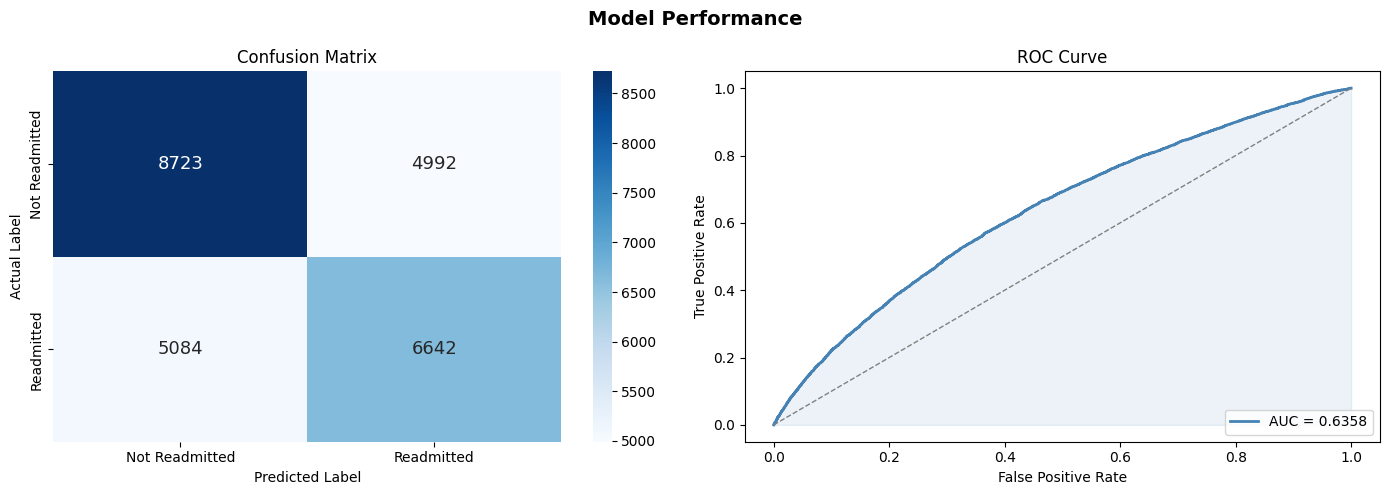

Metrics plot saved to: /Users/umair/Documents/Denovonet/neuroshield/data/output/metrics_plots.png


In [36]:
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec  = recall_score(y_test, y_pred, zero_division=0)
f1   = f1_score(y_test, y_pred, zero_division=0)
auc  = roc_auc_score(y_test, y_score)

print('=' * 45)
print('  Model Performance on Test Set')
print('=' * 45)
print(f'  Accuracy   : {acc:.4f}  ({acc*100:.2f}%)')
print(f'  Precision  : {prec:.4f}')
print(f'  Recall     : {rec:.4f}')
print(f'  F1 Score   : {f1:.4f}')
print(f'  AUC-ROC    : {auc:.4f}')
print('=' * 45)

# ── Plots ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Performance', fontsize=14, fontweight='bold')

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Not Readmitted', 'Readmitted'],
            yticklabels=['Not Readmitted', 'Readmitted'],
            annot_kws={'size': 13})
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('Actual Label')

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_score)
axes[1].plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {auc:.4f}')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1)
axes[1].fill_between(fpr, tpr, alpha=0.1, color='steelblue')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend(loc='lower right')

plt.tight_layout()
plot_path = os.path.join(OUTPUT_DIR, 'metrics_plots.png')
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Metrics plot saved to: {plot_path}')

In [37]:
# ── Feature Importance ────────────────────────────────────────────────
importance_df = (
    scores_df
    .sort_values('contribution_weight', ascending=False)
    .reset_index(drop=True)
)
importance_df.index = importance_df.index + 1

print('=' * 85)
print('  Feature Importance  (ranked by contribution weight = |2 * raw_score - 100|)')
print('=' * 85)
print(importance_df[['feature', 'raw_score', 'contribution_weight', 'direction']].to_string())
print('=' * 85)

  Feature Importance  (ranked by contribution weight = |2 * raw_score - 100|)
                       feature  raw_score  contribution_weight                direction
1         had_inpatient_visits    61.2667              22.5334  positive (+readmission)
2         had_emergency_visits    56.9115              13.8230  positive (+readmission)
3        had_outpatient_visits    56.6822              13.3644  positive (+readmission)
4               repaglinide_on    54.0748               8.1496  positive (+readmission)
5                  acarbose_on    53.9517               7.9034  positive (+readmission)
6                  miglitol_on    53.9242               7.8484  positive (+readmission)
7               high_diagnoses    53.9163               7.8326  positive (+readmission)
8               nateglinide_on    53.9124               7.8248  positive (+readmission)
9            chlorpropamide_on    53.9045               7.8090  positive (+readmission)
10               tolazamide_on    53.8966 

## Section 13: Save Trained Model

In [38]:
model_data = {
    'raw_scores':     raw_scores,
    'threshold':      round(float(threshold), 4),
    'feature_count':  len(feature_cols),
    'training_rows':  len(X_train),
    'label_encoding': {
        'readmitted':     1,
        'not_readmitted': 0
    }
}

model_path = os.path.join(OUTPUT_DIR, 'trained_model.json')
with open(model_path, 'w') as f:
    json.dump(model_data, f, indent=2)

print(f'Model saved to  : {model_path}')
print(f'Features        : {model_data["feature_count"]}')
print(f'Training rows   : {model_data["training_rows"]}')
print(f'Threshold       : {model_data["threshold"]}')
print('\nSample raw scores:')
for feat, score in list(raw_scores.items())[:5]:
    print(f'  {feat:<45} {score:.4f}')

Model saved to  : /Users/umair/Documents/Denovonet/neuroshield/data/output/trained_model.json
Features        : 52
Training rows   : 76322
Threshold       : -210.4996

Sample raw scores:
  race_caucasian                                49.4222
  race_african_american                         52.2785
  race_hispanic                                 53.5481
  race_asian                                    53.7420
  race_other                                    53.5992
